In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [ ]:
os.chdir("/Users/kaiping/Desktop/olist_project/data") 
os.getcwd()

### 1. 資料欄位過濾

In [3]:
df_translation = pd.read_csv("raw/product_category_name_translation.csv")
df_sellers     = pd.read_csv("raw/olist_sellers_dataset.csv")
df_products    = pd.read_csv("raw/olist_products_dataset.csv")
df_orders      = pd.read_csv("raw/olist_orders_dataset.csv")
df_order_reviews  = pd.read_csv("raw/olist_order_reviews_dataset.csv")
df_order_payments = pd.read_csv("raw/olist_order_payments_dataset.csv")
df_order_items    = pd.read_csv("raw/olist_order_items_dataset.csv")
df_geolocation    = pd.read_csv("raw/olist_geolocation_dataset.csv")
df_customers      = pd.read_csv("raw/olist_customers_dataset.csv")


In [7]:

# =========================
# 0. analysis end
# =========================
# 你這次寫的是 "2018-05-31"，我先用整天截止
# 如果你要沿用舊版 2018-05-31 15:00:00，改這一行就好
analysis_end = pd.Timestamp("2018-05-31 23:59:59")

# =========================
# 1. helper functions
# =========================
def mode_or_nan(s):
    s = pd.Series(s).dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0]

def join_unique_ids(s):
    vals = pd.Series(s).dropna().astype(str).unique().tolist()
    vals = sorted(vals)
    return "|".join(vals)

# =========================
# 2. 保留需要欄位
# =========================
orders = df_orders[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

customers = df_customers[
    [
        "customer_id",
        "customer_unique_id",
        "customer_state"
    ]
].copy()

order_items = df_order_items[
    [
        "order_id",
        "price",
        "freight_value"
    ]
].copy()

order_reviews = df_order_reviews[
    [
        "order_id",
        "review_score"
    ]
].copy()

# =========================
# 3. 型態清理
# =========================
for col in [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

order_items["price"] = pd.to_numeric(order_items["price"], errors="coerce")
order_items["freight_value"] = pd.to_numeric(order_items["freight_value"], errors="coerce")
order_reviews["review_score"] = pd.to_numeric(order_reviews["review_score"], errors="coerce")

order_items["price"] = order_items["price"].fillna(0)
order_items["freight_value"] = order_items["freight_value"].fillna(0)

# =========================
# 4. 分析口徑
#    1) 只留 delivered
#    2) 只留 analysis_end 以前
# =========================
orders = orders.loc[
    (orders["order_status"] == "delivered") &
    (orders["order_purchase_timestamp"].notna()) &
    (orders["order_purchase_timestamp"] <= analysis_end)
].copy()

# =========================
# 5. 掛上 customer_unique_id / customer_state
# =========================
orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

orders = orders.dropna(subset=["customer_unique_id"]).copy()

# =========================
# 6. order_items 先彙總到 order level
#    GMV = total_price + total_freight
# =========================
order_amount = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum")
    )
)

order_amount["gmv"] = order_amount["total_price"] + order_amount["total_freight"]

# =========================
# 7. review 先彙總到 order level
# =========================
order_review_agg = (
    order_reviews.groupby("order_id", as_index=False)
    .agg(
        avg_review=("review_score", "mean")
    )
)

# =========================
# 8. 併回 order level base
# =========================
order_base = (
    orders
    .merge(order_amount, on="order_id", how="left")
    .merge(order_review_agg, on="order_id", how="left")
)

# 沒有 item / review 的補值
order_base["total_price"] = order_base["total_price"].fillna(0)
order_base["total_freight"] = order_base["total_freight"].fillna(0)
order_base["gmv"] = order_base["gmv"].fillna(0)

# =========================
# 9. 先在 order level 算物流指標
# =========================
order_base["delivery_days"] = (
    order_base["order_delivered_customer_date"] - order_base["order_purchase_timestamp"]
).dt.total_seconds() / 86400

order_base["delivery_delay_days"] = (
    order_base["order_delivered_customer_date"] - order_base["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

# order-level 是否晚到
order_base["late_flag_order"] = (order_base["delivery_delay_days"] > 0).astype(int)

# =========================
# 10. 依你的口徑聚合成「購買事件」
#     同一顧客、同一 timestamp = 同一購買事件
# =========================
event_level = (
    order_base.groupby(
        ["customer_unique_id", "order_purchase_timestamp"],
        as_index=False
    )
    .agg(
        order_id=("order_id", join_unique_ids),  # 合併後的 order_id 清單
        customer_state=("customer_state", mode_or_nan),

        # 事件日期：用 max，代表整個購買事件最終完成時間
        order_delivered_customer_date=("order_delivered_customer_date", "max"),
        order_estimated_delivery_date=("order_estimated_delivery_date", "max"),

        # 金額
        total_price=("total_price", "sum"),
        total_freight=("total_freight", "sum"),
        gmv=("gmv", "sum"),

        # 評分
        avg_review=("avg_review", "mean"),

        # 補充：這個購買事件內有幾張 order 晚到
        late_order_cnt=("late_flag_order", "sum")
    )
)

# =========================
# 11. 在 event level 重算物流欄位
# =========================
event_level["delivery_days"] = (
    event_level["order_delivered_customer_date"] - event_level["order_purchase_timestamp"]
).dt.total_seconds() / 86400

event_level["delivery_delay_days"] = (
    event_level["order_delivered_customer_date"] - event_level["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

# 事件層級 late_flag：只要此購買事件最終完成時間晚於最終預估時間就記 1
event_level["late_flag"] = (event_level["delivery_delay_days"] > 0).astype(int)

# =========================
# 12. 最後只保留你要的欄位
# =========================
final_cols = [
    "order_id",
    "customer_unique_id",
    "order_purchase_timestamp",
    "customer_state",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "delivery_days",
    "delivery_delay_days",
    "late_flag",
    "avg_review",
    "gmv"
]

purchase_event_df = event_level[final_cols].copy()

# 如果你想保留拆解欄位，也可以改用下面這組：
# final_cols_extended = final_cols + ["total_price", "total_freight", "late_order_cnt"]
# purchase_event_df = event_level[final_cols_extended].copy()

# =========================
# 13. 檢查結果
# =========================
print("purchase_event_df shape:", purchase_event_df.shape)
display(purchase_event_df.head())

print("\n缺失值檢查：")
display(purchase_event_df.isna().sum())

print("\nGMV summary:")
display(purchase_event_df["gmv"].describe())

print("\navg_review summary:")
display(purchase_event_df["avg_review"].describe())

purchase_event_df shape: (77207, 11)


,order_id,customer_unique_id,order_purchase_timestamp,customer_state,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,late_flag,avg_review,gmv
0,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,SP,2018-05-16 20:48:00,2018-05-21,6.411111,-4.133333,0,5.0,141.90
1,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,SP,2018-05-10 18:02:00,2018-05-15,3.285417,-4.248611,0,4.0,27.19
2,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,SC,2017-04-05 14:38:00,2017-04-07,25.731250,-1.390278,0,3.0,86.22
3,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,PA,2017-11-01 21:23:00,2017-11-13,20.037500,-11.109028,0,4.0,43.62
4,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,SP,2017-11-27 23:08:00,2017-12-05,13.140972,-7.036111,0,5.0,196.89



缺失值檢查：


order_id                           0
customer_unique_id                 0
order_purchase_timestamp           0
customer_state                     0
order_delivered_customer_date      2
order_estimated_delivery_date      0
delivery_days                      2
delivery_delay_days                2
late_flag                          0
avg_review                       551
gmv                                0
dtype: int64


GMV summary:


count    77207.000000
mean       160.535917
std        218.321820
min         10.070000
25%         62.015000
50%        105.510000
75%        177.390000
max      13664.080000
Name: gmv, dtype: float64


avg_review summary:


count    76656.000000
mean         4.120579
std          1.305582
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: avg_review, dtype: float64

### 1.1 處理缺失值

刪除
order_delivered_customer_date 缺失的 2 筆  
連同：  
delivery_days  
delivery_delay_days  

avg_review 保留 NaN
新增
has_review

In [8]:
# 1. 刪除物流時間缺失的事件（極少數，且無法可靠推導）
purchase_event_df = purchase_event_df.dropna(
    subset=["order_delivered_customer_date", "delivery_days", "delivery_delay_days"]
).copy()

# 2. review 不做中位數補值，保留缺失，並建立是否有評論旗標
purchase_event_df["has_review"] = purchase_event_df["avg_review"].notna().astype(int)

In [9]:
print("purchase_event_df shape:", purchase_event_df.shape)
display(purchase_event_df.head())

print("\n缺失值檢查：")
display(purchase_event_df.isna().sum())

purchase_event_df shape: (77205, 12)


,order_id,customer_unique_id,order_purchase_timestamp,customer_state,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,late_flag,avg_review,gmv,has_review
0,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,SP,2018-05-16 20:48:00,2018-05-21,6.411111,-4.133333,0,5.0,141.90,1
1,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,SP,2018-05-10 18:02:00,2018-05-15,3.285417,-4.248611,0,4.0,27.19,1
2,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,SC,2017-04-05 14:38:00,2017-04-07,25.731250,-1.390278,0,3.0,86.22,1
3,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,PA,2017-11-01 21:23:00,2017-11-13,20.037500,-11.109028,0,4.0,43.62,1
4,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,SP,2017-11-27 23:08:00,2017-12-05,13.140972,-7.036111,0,5.0,196.89,1



缺失值檢查：


order_id                           0
customer_unique_id                 0
order_purchase_timestamp           0
customer_state                     0
order_delivered_customer_date      0
order_estimated_delivery_date      0
delivery_days                      0
delivery_delay_days                0
late_flag                          0
avg_review                       551
gmv                                0
has_review                         0
dtype: int64

### 2. 顧客價值是否高度集中？

In [10]:
customer_value = (
    purchase_event_df
    .groupby("customer_unique_id", as_index=False)
    .agg(
        total_gmv=("gmv", "sum")
    )
)

print(customer_value.shape)
customer_value.head()

(75385, 2)


,customer_unique_id,total_gmv
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [17]:
customer_value["total_gmv"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    75385.000000
mean       164.411590
std        223.456266
min         10.070000
25%         63.000000
50%        107.200000
75%        181.680000
90%        317.800000
95%        466.184000
99%       1085.424800
max      13664.080000
Name: total_gmv, dtype: float64

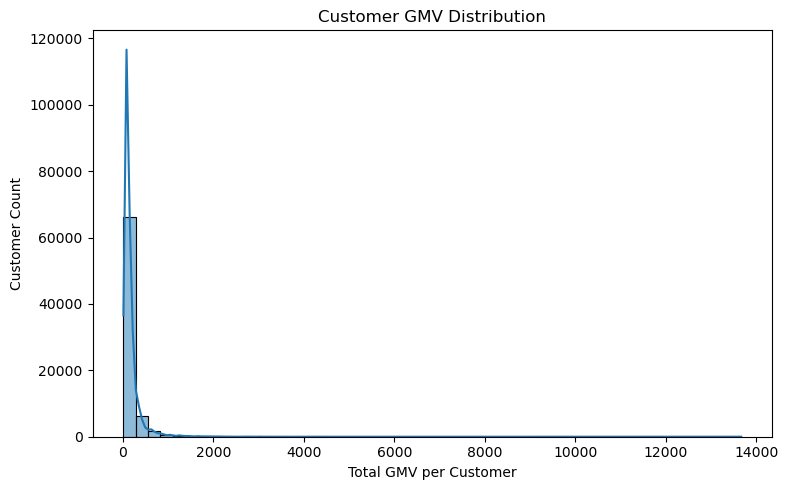

In [11]:
# GMV分佈
plt.figure(figsize=(8, 5))
sns.histplot(customer_value["total_gmv"], bins=50, kde=True)
plt.title("Customer GMV Distribution")
plt.xlabel("Total GMV per Customer")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

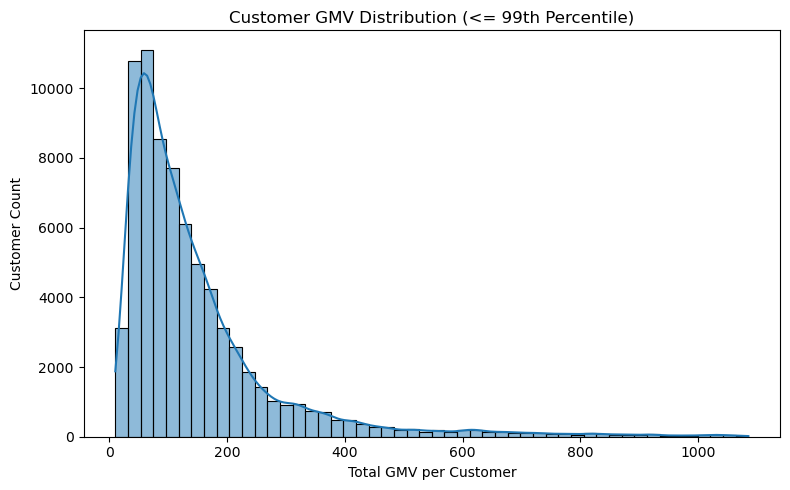

In [18]:
p99 = customer_value["total_gmv"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(
    customer_value.loc[customer_value["total_gmv"] <= p99, "total_gmv"],
    bins=50,
    kde=True
)
plt.title("Customer GMV Distribution (<= 99th Percentile)")
plt.xlabel("Total GMV per Customer")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

In [28]:
# 累積顧客佔比 vs 累積 GMV 佔比 curve (顧客價值排序表)
# log_total_gmv: 對GMV做log transform (因為gmv高度右偏) 
# customer_rank: 根據gmv做排名
# customer_pct: 在全體顧客價值的前幾％ (customer_rank / 總顧客數) 
# cum_gmv: 從第 1 名累積到當前顧客的總 GMV
# cum_gmv_pct: 累積貢獻了多少GMV比例


In [13]:
customer_rank = customer_value.sort_values("total_gmv", ascending=False).reset_index(drop=True)

customer_rank["customer_rank"] = np.arange(1, len(customer_rank) + 1)
customer_rank["customer_pct"] = customer_rank["customer_rank"] / len(customer_rank)

customer_rank["cum_gmv"] = customer_rank["total_gmv"].cumsum()
customer_rank["cum_gmv_pct"] = customer_rank["cum_gmv"] / customer_rank["total_gmv"].sum()

customer_rank.head()

,customer_unique_id,total_gmv,log_total_gmv,customer_rank,customer_pct,cum_gmv,cum_gmv_pct
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,9.522599,1,0.000013,13664.08,0.001102
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,8.932296,2,0.000027,21235.71,0.001713
2,dc4802a71eae9be1dd28f5d788ceb526,6929.31,8.843660,3,0.000040,28165.02,0.002272
3,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,8.813983,4,0.000053,34891.68,0.002815
4,4007669dec559734d6f53e029e360987,6081.54,8.713178,5,0.000066,40973.22,0.003306


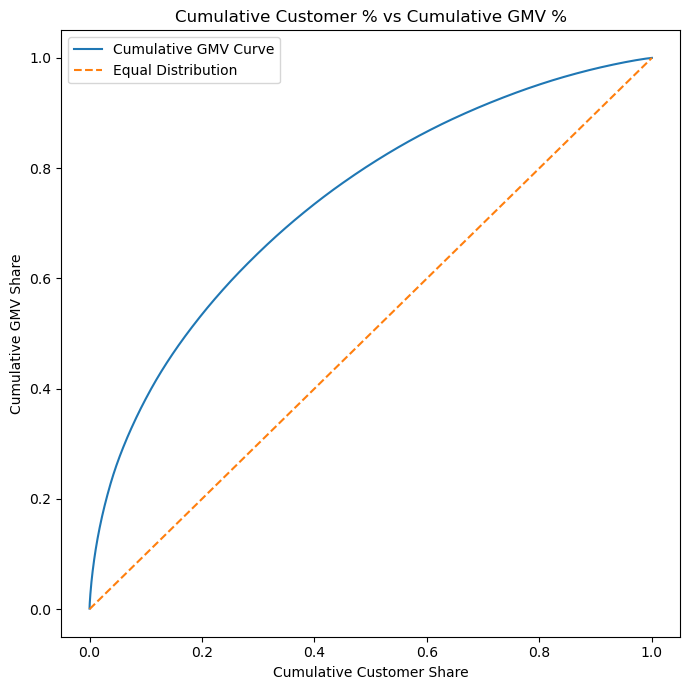

In [14]:
plt.figure(figsize=(7, 7))

plt.plot(
    customer_rank["customer_pct"],
    customer_rank["cum_gmv_pct"],
    label="Cumulative GMV Curve"
)

# 參考線：完全平均分布
plt.plot([0, 1], [0, 1], linestyle="--", label="Equal Distribution")

plt.title("Cumulative Customer % vs Cumulative GMV %")
plt.xlabel("Cumulative Customer Share")
plt.ylabel("Cumulative GMV Share")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
def gmv_share_at_top_pct(df, pct):
    n = int(np.ceil(len(df) * pct))
    return df.head(n)["total_gmv"].sum() / df["total_gmv"].sum()

top_10_share = gmv_share_at_top_pct(customer_rank, 0.10)
top_20_share = gmv_share_at_top_pct(customer_rank, 0.20)
top_50_share = gmv_share_at_top_pct(customer_rank, 0.50)

print(f"Top 10% customers contribute {top_10_share:.2%} of total GMV")
print(f"Top 20% customers contribute {top_20_share:.2%} of total GMV")
print(f"Top 50% customers contribute {top_50_share:.2%} of total GMV")

Top 10% customers contribute 38.16% of total GMV
Top 20% customers contribute 53.48% of total GMV
Top 50% customers contribute 80.73% of total GMV


### 3. 前20%顧客回購數量分析

In [20]:
top20_n = int(np.ceil(len(customer_rank) * 0.20))

top20_customers = customer_rank.head(top20_n)[
    ["customer_unique_id", "total_gmv"]
].copy()

print("top20 customer count:", len(top20_customers))
top20_customers.head()

top20 customer count: 15077


,customer_unique_id,total_gmv
0,0a0a92112bd4c708ca5fde585afaa872,13664.08
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63
2,dc4802a71eae9be1dd28f5d788ceb526,6929.31
3,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
4,4007669dec559734d6f53e029e360987,6081.54


In [21]:
top20_orders = orders.merge(
    top20_customers[["customer_unique_id"]],
    on="customer_unique_id",
    how="inner"
)

top20_order_cnt = (
    top20_orders.groupby("customer_unique_id", as_index=False)
    .agg(
        raw_order_cnt=("order_id", "nunique")
    )
)

top20_order_cnt = top20_customers.merge(
    top20_order_cnt,
    on="customer_unique_id",
    how="left"
)

top20_order_cnt["raw_order_cnt"] = top20_order_cnt["raw_order_cnt"].fillna(0).astype(int)

top20_order_cnt.head()

,customer_unique_id,total_gmv,raw_order_cnt
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,1
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,2
2,dc4802a71eae9be1dd28f5d788ceb526,6929.31,1
3,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,1
4,4007669dec559734d6f53e029e360987,6081.54,1


raw_order_cnt: order:表中此客人有幾筆訂單  
purchase_event_cnt某:位顧客有幾次購買事件，同一顧客 + 同一 order_purchase_timestamp = 1 次購買事件

In [22]:
top20_events = purchase_event_df.merge(
    top20_customers[["customer_unique_id"]],
    on="customer_unique_id",
    how="inner"
)

top20_event_cnt = (
    top20_events.groupby("customer_unique_id", as_index=False)
    .agg(
        purchase_event_cnt=("order_purchase_timestamp", "count")
    )
)

top20_order_cnt = top20_order_cnt.merge(
    top20_event_cnt,
    on="customer_unique_id",
    how="left"
)

top20_order_cnt["purchase_event_cnt"] = (
    top20_order_cnt["purchase_event_cnt"].fillna(0).astype(int)
)

top20_order_cnt.head()

,customer_unique_id,total_gmv,raw_order_cnt,purchase_event_cnt
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,1,1
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,2,1
2,dc4802a71eae9be1dd28f5d788ceb526,6929.31,1,1
3,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,1,1
4,4007669dec559734d6f53e029e360987,6081.54,1,1


In [23]:
top20_order_cnt[["raw_order_cnt", "purchase_event_cnt"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

,raw_order_cnt,purchase_event_cnt
count,15077.000000,15077.000000
mean,1.093454,1.071699
std,0.357919,0.316007
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
90%,1.000000,1.000000
95%,2.000000,2.000000
99%,2.000000,2.000000


In [26]:
event_dist = (
    top20_order_cnt["purchase_event_cnt"]
    .value_counts()
    .sort_index()
    .reset_index()
)

event_dist.columns = ["purchase_event_cnt", "customer_count"]
event_dist["customer_rate"] = (
    event_dist["customer_count"] / event_dist["customer_count"].sum()
)

display(event_dist.head(15))

,purchase_event_cnt,customer_count,customer_rate
0,1,14147,0.938317
1,2,829,0.054984
2,3,76,0.005041
3,4,13,0.000862
4,5,5,0.000332
5,6,4,0.000265
6,7,2,0.000133
7,10,1,0.000066


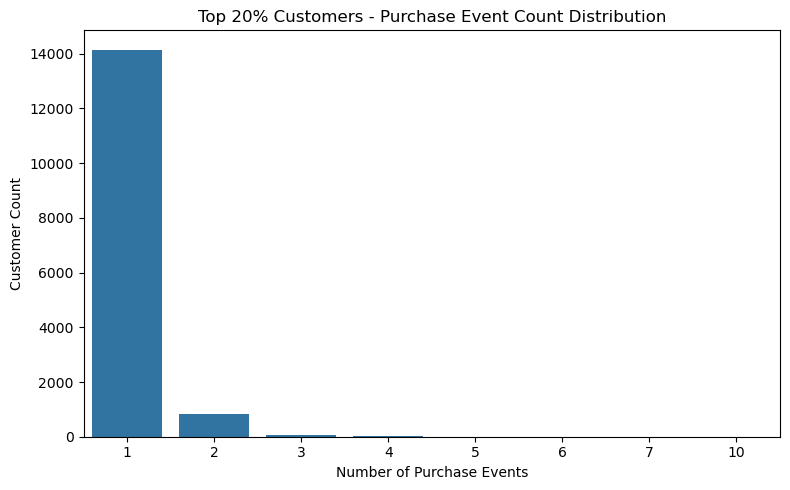

In [27]:
plt.figure(figsize=(8, 5))
sns.barplot(data=event_dist.head(15), x="purchase_event_cnt", y="customer_count")
plt.title("Top 20% Customers - Purchase Event Count Distribution")
plt.xlabel("Number of Purchase Events")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

前20%客人裡面回購率還是很低，在這群裡面93%的人還是只有買一次，顯示此群體之價值主要來自單次高金額交易，比較不像商業意義
上的高價值顧客，商業意義上的高價值顧客會多次回購。
專案的研究目的是辨識可持續累積價值的客人流失分析，所以後面再定義高價值顧客流失時，高價值顧客定義要考慮金額和回購次數。

### 4.高價值回購顧客樣本數量分析

In [30]:
customer_summary = (
    purchase_event_df
    .groupby("customer_unique_id")
    .agg(
        purchase_event_cnt=("order_id", "count"),
        total_gmv=("gmv", "sum")
    )
    .reset_index()
)

In [31]:
customer_summary = customer_summary.sort_values(
    "total_gmv", ascending=False
).reset_index(drop=True)

customer_summary["customer_rank"] = np.arange(1, len(customer_summary)+1)
customer_summary["customer_pct"] = (
    customer_summary["customer_rank"] / len(customer_summary)
)

In [32]:
high_value_repeat = customer_summary[
    (customer_summary["customer_pct"] <= 0.20) &
    (customer_summary["purchase_event_cnt"] >= 2)
].copy()

In [33]:
print("高價值回購顧客數:", len(high_value_repeat))
print("占全體顧客比例:", len(high_value_repeat) / len(customer_summary))

高價值回購顧客數: 930
占全體顧客比例: 0.012336671751674737


In [34]:
high_value_repeat["purchase_event_cnt"].describe()

count    930.000000
mean       2.162366
std        0.592819
min        2.000000
25%        2.000000
50%        2.000000
75%        2.000000
max       10.000000
Name: purchase_event_cnt, dtype: float64